# Compare LLM Types

Using locally loaded LLMs with Ollama

We will compare the behavior of several types of transformer based models:
- Base language models
- Fine tuned language models (instruct, code)
- Vision LLM
- LLM fine tuned for code

# Setup

## Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
import re
import sqlite3


from datetime import datetime, timedelta
from IPython.display import display, Markdown, clear_output
from pathlib import Path
from PIL import Image

## Setup LLM

In [2]:
def setup_clean_proxy():
    """Clear problematic proxy vars and set clean ones for VPN access"""
    print("Setting up clean proxy environment for VPN and LLM access...")
    env_backup = {}
    proxy_vars = ['http_proxy', 'https_proxy', 'HTTP_PROXY', 'HTTPS_PROXY', 'no_proxy', 'NO_PROXY']
    for var in proxy_vars:
        if var in os.environ:
            env_backup[var] = os.environ[var]
            del os.environ[var]
    
    os.environ['HTTPS_PROXY'] = 'http://127.0.0.1:16005'
    os.environ['HTTP_PROXY'] = 'http://127.0.0.1:16005'
    return env_backup

# Call at start
env_backup = setup_clean_proxy()
print(env_backup)

Setting up clean proxy environment for VPN and LLM access...
{'http_proxy': 'http://127.0.0.1:16005', 'https_proxy': 'http://127.0.0.1:16005', 'HTTP_PROXY': 'http://127.0.0.1:16005', 'HTTPS_PROXY': 'http://127.0.0.1:16005', 'no_proxy': '[fec0::*],[fc00::*],[fe80::*],100.64.*,172.16.*,192.168.*,10.*,127.*,169.254.*,localhost,*.local,vpnguistub', 'NO_PROXY': '[fec0::*],[fc00::*],[fe80::*],100.64.*,172.16.*,192.168.*,10.*,127.*,169.254.*,localhost,*.local,vpnguistub'}


In [3]:
import ollama

### msg to llm

In [4]:
def send_message_to_llm(message, model, system_message=None, streaming=True, max_tokens=8000):
    """Send a message to the LLM and return the response"""
    display(Markdown(f"Model: `{model}`"))
    display(Markdown(f"Answer to: **{message}**"))
    options = {}
    if max_tokens:
        options['num_predict'] = max_tokens
    if streaming:
        output = display(Markdown('Computing ...'), display_id=True)
        stream = ollama. chat(
            model=model,
            messages=[{'role': 'user', 'content': message}],
            stream=streaming,
            options=options if options else None,
            )
        streamed = ""
        for chunk in stream:
            streamed += chunk['message']['content']
            # clear_output(wait=True)
            output.update(Markdown(streamed))

        print(f"Done! in {len(streamed):,d} characters.")
        return streamed
    else:
        output = display(Markdown('Computing ...'), display_id=True)
        response = ollama.chat(
            model=model, 
            messages=[{'role': 'user', 'content': message}], 
            stream=False,
            options=options if options else None,
        )
        output.update(Markdown(response['message']['content']))
        print(f"Done! in {len(response['message']['content']):,d} characters.")
        return response

### msg to thinking llm

In [5]:
def send_message_to_llm_with_thinking_stream(message, model, system_message=None, streaming=True, max_tokens=8000):
    """Send message and parse thinking vs answer sections while streaming"""
    display(Markdown(f"Model: `{model}`"))
    display(Markdown(f"Answer to: **{message}**"))
    
    options = {}
    if max_tokens:
        options['num_predict'] = max_tokens
    
    if streaming:
        # Create display handles for thinking and answer
        thinking_output = display(Markdown("### 🧠 Thinking Process\n```\n\n```"), display_id=True)
        answer_output = display(Markdown("### 💡 Final Answer\n\n"), display_id=True)
        
        stream = ollama.chat(
            model=model,
            messages=[{'role': 'user', 'content': message}],
            stream=True,
            options=options if options else None,
        )
        
        streamed = ""
        thinking = ""
        answer = ""
        in_think_tag = False
        
        for chunk in stream:
            content = chunk['message']['content']
            streamed += content
            
            # Check for <think> tag opening
            if '<think>' in streamed and not in_think_tag:
                in_think_tag = True
                # Split at <think>
                parts = streamed.split('<think>', 1)
                if len(parts) > 1:
                    thinking = parts[1]
            
            # Check for </think> tag closing
            elif '</think>' in streamed and in_think_tag:
                in_think_tag = False
                # Split to separate thinking from answer
                parts = streamed.split('</think>', 1)
                if len(parts) > 1:
                    thinking = parts[0].split('<think>', 1)[1] if '<think>' in parts[0] else ""
                    answer = parts[1]
                    # Update both displays
                    thinking_output.update(Markdown(f"### 🧠 Thinking Process\n```\n{thinking}\n```"))
                    answer_output.update(Markdown(f"### 💡 Final Answer\n{answer}"))
            
            # While inside think tags
            elif in_think_tag:
                # Extract thinking content
                if '<think>' in streamed:
                    thinking = streamed.split('<think>', 1)[1]
                    thinking_output.update(Markdown(f"### 🧠 Thinking Process\n```\n{thinking}\n```"))
            
            # After think tags (or no think tags)
            else:
                # Check if we already closed think tags
                if '</think>' in streamed:
                    parts = streamed.split('</think>', 1)
                    if len(parts) > 1:
                        answer = parts[1]
                        answer_output.update(Markdown(f"### 💡 Final Answer\n{answer}"))
                else:
                    # No think tags at all, just show as answer
                    answer_output.update(Markdown(f"### 💡 Final Answer\n{streamed}"))
        
        print(f"Done! in {len(streamed):,d} characters.")
        
        # Final parse to ensure clean separation
        think_match = re.search(r'<think>(.*?)</think>', streamed, re.DOTALL)
        if think_match:
            thinking = think_match.group(1).strip()
            answer = re.sub(r'<think>.*?</think>', '', streamed, flags=re.DOTALL).strip()
        else:
            thinking = None
            answer = streamed
        
        return {'thinking': thinking, 'answer': answer, 'full': streamed}
    
    else:
        # Non-streaming version (unchanged)
        output = display(Markdown('Computing ...'), display_id=True)
        response = ollama.chat(
            model=model, 
            messages=[{'role': 'user', 'content': message}], 
            stream=False,
            options=options if options else None,
        )
        content = response['message']['content']
        
        think_match = re.search(r'<think>(.*?)</think>', content, re.DOTALL)
        if think_match:
            thinking = think_match.group(1).strip()
            answer = re.sub(r'<think>.*?</think>', '', content, flags=re.DOTALL).strip()
            
            display(Markdown("### 🧠 Thinking Process"))
            display(Markdown(f"```\n{thinking}\n```"))
            display(Markdown("### 💡 Final Answer"))
            display(Markdown(answer))
        else:
            output.update(Markdown(content))
            thinking = None
            answer = content
        
        print(f"Done! in {len(content):,d} characters.")
        return {'thinking': thinking, 'answer': answer, 'full': content}

### image to VLLM

In [6]:
def send_image_to_llm(message, image_path, model='llava:7b', streaming=True, max_tokens=8000):
    """Send a message with an image to a vision LLM"""
    display(Markdown(f"Model: `{model}`"))
    display(Markdown(f"Question: **{message}**"))
    display(Markdown(f"Image File: **{image_path.name}**"))

    im = Image.open(image_path)
    max_size = (512, 512)
    im.thumbnail(max_size, Image.Resampling.LANCZOS)    

    options = {}
    if max_tokens:
        options['num_predict'] = max_tokens
    
    if streaming:
        output = display(Markdown('Computing ...'), display_id=True)
        stream = ollama.chat(
            model=model,
            messages=[{
                'role': 'user',
                'content': message,
                'images': [image_path]  # Pass image path
            }],
            stream=True,
            options=options if options else None,
        )
        streamed = ""
        for chunk in stream:
            streamed += chunk['message']['content']
            output.update(Markdown(streamed))
        
        print(f"Done! in {len(streamed):,d} characters.")
        display(im)
        return streamed
    else:
        output = display(Markdown('Computing ...'), display_id=True)
        response = ollama.chat(
            model=model,
            messages=[{
                'role': 'user',
                'content': message,
                'images': [image_path]
            }],
            stream=False,
            options=options if options else None,
        )
        output.update(Markdown(response['message']['content']))
        print(f"Done! in {len(response['message']['content']):,d} characters.")
        display(im)
        return response['message']['content']

## Setup sqlite database

### Create a database if it does not exist yet

In [7]:
db_dir = Path('../db')
db_dir.mkdir(exist_ok=True)

# Database path
db_path = db_dir / 'crm.db'

# Remove existing database to start fresh
if db_path.exists():
    db_path.unlink()

# Connect to database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Create tables
cursor.execute('''
CREATE TABLE accounts (
    uid INTEGER PRIMARY KEY AUTOINCREMENT,
    account_name TEXT NOT NULL,
    city TEXT NOT NULL,
    country TEXT NOT NULL
)
''')

cursor.execute('''
CREATE TABLE products (
    uid INTEGER PRIMARY KEY AUTOINCREMENT,
    product_name TEXT NOT NULL,
    product_price REAL NOT NULL,
    delivery_leadtime INTEGER NOT NULL
)
''')

cursor.execute('''
CREATE TABLE orders (
    uid INTEGER PRIMARY KEY AUTOINCREMENT,
    account_id INTEGER NOT NULL,
    order_date TEXT NOT NULL,
    status TEXT NOT NULL,
    FOREIGN KEY (account_id) REFERENCES accounts(uid)
)
''')

cursor.execute('''
CREATE TABLE order_details (
    uid INTEGER PRIMARY KEY AUTOINCREMENT,
    order_id INTEGER NOT NULL,
    product_id INTEGER NOT NULL,
    quantity INTEGER NOT NULL,
    FOREIGN KEY (order_id) REFERENCES orders(uid),
    FOREIGN KEY (product_id) REFERENCES products(uid)
)
''')

# Insert dummy data for accounts
locations = [
    ('Shanghai', 'PRC'),
    ('Beijing', 'PRC'),
    ('Shenzhen', 'PRC'),
    ('Tokyo', 'Japan'),
    ('Seoul', 'Korea')
]

company_prefixes = ['TechStyle', 'FashionHub', 'ModernWear', 'GlobalTextile', 'UrbanThread', 
                   'StyleCraft', 'PremiumFabric', 'ElegantWear', 'TrendSetter', 'ChicOutfit',
                   'ClassicApparel', 'NovaDress', 'EliteGarment', 'SwiftFashion', 'LuxuryFit']

accounts_data = []
for i, prefix in enumerate(company_prefixes):
    city, country = random.choice(locations)
    accounts_data.append((f"{prefix} Inc", city, country))

cursor.executemany('INSERT INTO accounts (account_name, city, country) VALUES (?, ?, ?)', accounts_data)

# Insert dummy data for products (clothing items)
products_data = [
    ('Cotton T-Shirt', 19.99, 3),
    ('Denim Jeans', 59.99, 5),
    ('Leather Jacket', 149.99, 7),
    ('Wool Sweater', 79.99, 4),
    ('Silk Blouse', 89.99, 6),
    ('Linen Pants', 69.99, 4),
    ('Polo Shirt', 39.99, 3),
    ('Dress Shirt', 49.99, 4),
    ('Cargo Shorts', 34.99, 3),
    ('Hooded Sweatshirt', 54.99, 5),
    ('Blazer', 129.99, 6),
    ('Pencil Skirt', 44.99, 4),
    ('Maxi Dress', 99.99, 5),
    ('Cardigan', 64.99, 4),
    ('Chinos', 54.99, 4),
    ('Track Pants', 39.99, 3),
    ('Tank Top', 14.99, 2),
    ('Bomber Jacket', 119.99, 6),
    ('Trench Coat', 179.99, 8),
    ('Cashmere Scarf', 84.99, 5)
]

cursor.executemany('INSERT INTO products (product_name, product_price, delivery_leadtime) VALUES (?, ?, ?)', products_data)

# Insert dummy data for orders
order_statuses = ['Pending', 'Processing', 'Shipped', 'Delivered', 'Cancelled']
base_date = datetime(2024, 1, 1)

orders_data = []
for i in range(50):
    account_id = random.randint(1, len(accounts_data))
    days_offset = random.randint(0, 365)
    order_date = (base_date + timedelta(days=days_offset)).strftime('%Y-%m-%d')
    status = random.choice(order_statuses)
    orders_data.append((account_id, order_date, status))

cursor.executemany('INSERT INTO orders (account_id, order_date, status) VALUES (?, ?, ?)', orders_data)

# Insert dummy data for order_details
order_details_data = []
for order_id in range(1, 51):
    # Each order has 1-5 line items
    num_items = random.randint(1, 5)
    for _ in range(num_items):
        product_id = random.randint(1, len(products_data))
        quantity = random.randint(1, 10)
        order_details_data.append((order_id, product_id, quantity))

cursor.executemany('INSERT INTO order_details (order_id, product_id, quantity) VALUES (?, ?, ?)', order_details_data)

# Commit and close
conn.commit()
conn.close()

print(f"✓ Database created at: {db_path}")
print(f"✓ {len(accounts_data)} accounts inserted")
print(f"✓ {len(products_data)} products inserted")
print(f"✓ {len(orders_data)} orders inserted")
print(f"✓ {len(order_details_data)} order details inserted")

✓ Database created at: ../db/crm.db
✓ 15 accounts inserted
✓ 20 products inserted
✓ 50 orders inserted
✓ 159 order details inserted


### query_db

In [8]:
def query_db(sql_query, db_path='../db/crm.db'):
    """Execute a SQL query and return results as a pandas DataFrame"""
    conn = sqlite3.connect(db_path)
    try:
        df = pd.read_sql_query(sql_query, conn)
        return df
    finally:
        conn.close()


query_db("SELECT * FROM accounts LIMIT 5")

,uid,account_name,city,country
0,1,TechStyle Inc,Shanghai,PRC
1,2,FashionHub Inc,Shanghai,PRC
2,3,ModernWear Inc,Shenzhen,PRC
3,4,GlobalTextile Inc,Beijing,PRC
4,5,UrbanThread Inc,Shenzhen,PRC


In [9]:
df = query_db(
    "SELECT * FROM sqlite_master WHERE type='table'"
)
db_schema = '\n'.join(df.sql.to_list())
print(db_schema)

CREATE TABLE accounts (
    uid INTEGER PRIMARY KEY AUTOINCREMENT,
    account_name TEXT NOT NULL,
    city TEXT NOT NULL,
    country TEXT NOT NULL
)
CREATE TABLE sqlite_sequence(name,seq)
CREATE TABLE products (
    uid INTEGER PRIMARY KEY AUTOINCREMENT,
    product_name TEXT NOT NULL,
    product_price REAL NOT NULL,
    delivery_leadtime INTEGER NOT NULL
)
CREATE TABLE orders (
    uid INTEGER PRIMARY KEY AUTOINCREMENT,
    account_id INTEGER NOT NULL,
    order_date TEXT NOT NULL,
    status TEXT NOT NULL,
    FOREIGN KEY (account_id) REFERENCES accounts(uid)
)
CREATE TABLE order_details (
    uid INTEGER PRIMARY KEY AUTOINCREMENT,
    order_id INTEGER NOT NULL,
    product_id INTEGER NOT NULL,
    quantity INTEGER NOT NULL,
    FOREIGN KEY (order_id) REFERENCES orders(uid),
    FOREIGN KEY (product_id) REFERENCES products(uid)
)


### sql_prompt

In [10]:
question = "What are the companies in the database?"

def sql_prompt(question):
    return f""" 
    ### Instructions:
    Your task is to convert a question into a SQL query, given a Postgres database schema.
    Adhere to these rules:
    - **Deliberately go through the question and database schema word by word** to appropriately answer the question
    - **Use Table Aliases** to prevent ambiguity. For example, `SELECT table1.col1, table2.col1 FROM table1 JOIN table2 ON table1.id = table2.id`.
    - When creating a ratio, always cast the numerator as float

    ### Input:
    Generate a SQL query that answers the question `{question}`.
    This query will run on a database whose schema is represented in this string:

    CREATE TABLE accounts (
        uid INTEGER PRIMARY KEY AUTOINCREMENT,
        company_name TEXT NOT NULL,
        city TEXT NOT NULL,
        country TEXT NOT NULL
    );

    CREATE TABLE products (
        uid INTEGER PRIMARY KEY AUTOINCREMENT,
        product_name TEXT NOT NULL,
        product_price REAL NOT NULL,
        delivery_leadtime INTEGER NOT NULL
    )
    ;

    CREATE TABLE orders (
        uid INTEGER PRIMARY KEY AUTOINCREMENT,
        account_id INTEGER NOT NULL,
        order_date TEXT NOT NULL,
        status TEXT NOT NULL,
        FOREIGN KEY (account_id) REFERENCES accounts(uid)
    )
    ;

    CREATE TABLE order_details (
        uid INTEGER PRIMARY KEY AUTOINCREMENT,
        order_id INTEGER NOT NULL,
        product_id INTEGER NOT NULL,
        quantity INTEGER NOT NULL,
        FOREIGN KEY (order_id) REFERENCES orders(uid),
        FOREIGN KEY (product_id) REFERENCES products(uid)
    )


    ### Response:
    Based on your instructions, here is the SQL query I have generated to answer the question : `{question}`:

    sql statement starts here:
    """

# print(sql_prompt(question) )

### send_message_llm_for_sql

In [11]:
def send_message_llm_for_sql(message, model, system_message=None, max_tokens=8000):
    """Send a message to the LLM and return the response"""
    display(Markdown(f"Model: `{model}`"))
    # display(Markdown(f"Answer to: **{message}**"))
    options = {}
    if max_tokens:
        options['num_predict'] = max_tokens
    # if streaming:
    # output = display(Markdown('Computing ...'), display_id=True)
    stream = ollama. chat(
        model=model,
        messages=[{'role': 'user', 'content': message}],
        stream=True,
        options=options if options else None,
        )
    streamed = ""
    for chunk in stream:
        streamed += chunk['message']['content']
        # output.update(Markdown(streamed))

    print(f"Done! in {len(streamed):,d} characters.")
    return streamed
    # else:
    # output = display(Markdown('Computing ...'), display_id=True)
    # response = ollama.chat(
    #     model=model, 
    #     messages=[{'role': 'user', 'content': message}], 
    #     stream=False,
    #     options=options if options else None,
    # )
    # output.update(Markdown(response['message']['content']))
    # print(f"Done! in {len(response['message']['content']):,d} characters.")
    # return response

### extract_sql

In [12]:
def extract_sql(response_text):
    """Extract SQL code from LLM response"""
    
    # Try to find SQL in code blocks first
    code_block_match = re.search(r'```sql\n(.*?)\n```', response_text, re.DOTALL | re.IGNORECASE)
    if code_block_match:
        return code_block_match.group(1).strip()
    
    # Try generic code blocks
    code_block_match = re.search(r'```\n(.*?)\n```', response_text, re.DOTALL)
    if code_block_match:
        return code_block_match.group(1).strip()
    
    # Look for lines starting with SQL keywords
    lines = response_text.strip().split('\n')
    sql_lines = []
    in_sql = False
    
    for line in lines:
        line_stripped = line.strip()
        # Start capturing when we see SQL keywords
        if re.match(r'^(SELECT|INSERT|UPDATE|DELETE|WITH|CREATE)', line_stripped, re.IGNORECASE):
            in_sql = True
        
        if in_sql:
            sql_lines.append(line)
            # Stop at semicolon
            if ';' in line:
                break
    
    if sql_lines:
        return '\n'.join(sql_lines).strip()
    
    # If nothing found, return the whole response
    return response_text.strip()

# Compare LLM types

In [13]:
models = sorted([e['model'] for e in ollama.list()['models']])
models

['bge-m3:latest',
 'codellama:7b',
 'deepseek-r1:7b',
 'deepseek-r1:8b',
 'gemma3:4b',
 'granite3.2-vision:latest',
 'llama3.1:8b',
 'llama3.2:1b-instruct-fp16',
 'llama3.2:1b-text-fp16',
 'llama3.2:3b',
 'llava:7b',
 'mxbai-embed-large:335m',
 'nomic-embed-text:latest',
 'qwen2.5:3b',
 'qwen2.5:7b',
 'qwen3:8b',
 'xitao/bge-reranker-v2-m3:latest']

## Use a LLM with Ollama

In [14]:
model_checkpoint = 'gemma3:4b'
query = "Why is the sky blue?"

output = send_message_to_llm(query, model_checkpoint, streaming=True)

Model: `gemma3:4b`

Answer to: **Why is the sky blue?**

That's a fantastic question, and one that's fascinated people for centuries! The short answer is: **it's due to a phenomenon called Rayleigh scattering.** Here's a more detailed explanation:

**1. Sunlight is Made of All Colors:**

* Sunlight might *look* white to us, but it's actually composed of all the colors of the rainbow – red, orange, yellow, green, blue, and violet.  Think of a prism splitting sunlight into its component colors.

**2. Scattering by Air Molecules:**

* As sunlight enters the Earth's atmosphere, it collides with tiny air molecules (mostly nitrogen and oxygen).
* This collision causes the light to scatter in different directions.

**3. Rayleigh Scattering – The Key:**

* **Rayleigh scattering** specifically describes how shorter wavelengths of light (like blue and violet) are scattered *much* more effectively than longer wavelengths (like red and orange).  This is because the amount of scattering is inversely proportional to the fourth power of the wavelength.  (That's a fancy way of saying shorter wavelengths are scattered *way* more strongly.)

**4. Why Blue, Not Violet?**

* Violet light is actually scattered *even more* than blue. However, there are a few reasons why we see the sky as blue:
    * **Sunlight emits less violet light than blue.** The sun simply doesn’t produce as much violet light to begin with.
    * **Our eyes are more sensitive to blue than violet.**  Human eyes are more sensitive to blue wavelengths.
    * **Atmospheric absorption:** Some violet light is absorbed by the upper atmosphere.

**In short, blue light is scattered all over the sky because it's the color most readily affected by the tiny air molecules.**  This scattered blue light reaches our eyes from all directions, making the sky appear blue.


**Think of it like this:** Imagine throwing a handful of small balls (blue light) and larger balls (red light) into a bumpy field. The smaller balls will bounce around in all directions, while the larger balls will mostly keep going straight.

---

**Resources for further learning:**

* **NASA:** [https://science.nasa.gov/atmosphere/why-is-the-sky-blue/](https://science.nasa.gov/atmosphere/why-is-the-sky-blue/)
* **National Geographic:** [https://www.nationalgeographic.com/science/phenomena/sky-blue/](https://www.nationalgeographic.com/science/phenomena/sky-blue/)


Do you want to explore any specific aspect of this explanation, such as:

*   Why sunsets are red?
*   The role of particles in scattering (like dust or pollution)?

Done! in 2,517 characters.


## Compare Base Model and Instruct Model

We pick `llama3.2` and use the base model and the finetuned model for instructions. We will use a very small model version.
- **base** (text): `llama3.2:1b-text-fp16`
- **instruct** (instruct): `llama3.2:1b-instruct-fp16`

In [39]:
base_model = 'llama3.2:1b-text-fp16'
instruct_model = 'llama3.2:1b-instruct-fp16'
query = "Why is the sky blue?"

### Instruct Model

In [40]:
output = send_message_to_llm(query, instruct_model, streaming=True)  

Model: `llama3.2:1b-instruct-fp16`

Answer to: **Why is the sky blue?**

The sky appears blue to us because of a phenomenon called Rayleigh scattering, named after the British physicist Lord Rayleigh. He discovered that shorter (blue) wavelengths of light are scattered more than longer (red) wavelengths when they interact with small particles in the atmosphere, such as nitrogen and oxygen molecules.

Here's what happens:

1. When sunlight enters Earth's atmosphere, it encounters tiny molecules of gases like nitrogen and oxygen.
2. The shorter blue wavelengths of light are scattered by these molecules in all directions, but they are scattered more than the longer red wavelengths.
3. This is because the smaller molecules have a greater effect on scattering shorter wavelengths due to their small size and high mobility.
4. As a result, about 7% of the sunlight that enters the atmosphere is scattered in a direction that we perceive as blue.

The other 93% of the sunlight that reaches our eyes is either:

* Refracted (bent) as it passes through the Earth's atmosphere
* Absorbed by atmospheric gases or particles
* Scattered by larger particles, like dust and water vapor

This scattering effect gives the sky its blue color during the daytime, especially in the lower part of the atmosphere where the air is thinner.

It's worth noting that the sky can appear different colors at night, when there are fewer molecules to scatter the shorter wavelengths. The sky can take on a reddish hue due to the presence of more dust and gas particles, which absorb blue light and scatter red light back towards our eyes.

Done! in 1,546 characters.


### Base Model

In [17]:
output = send_message_to_llm(query, base_model, streaming=True)

Model: `llama3.2:1b-text-fp16`

Answer to: **Why is the sky blue?**

 Why do we see more stars at night than during the day?
Astronomers have discovered a new kind of star, which astronomers call 'blue stragglers'. Astronomers think that these mysterious stars may be remnants of the Big Bang. The scientists from Harvard University and McGill University in Canada found evidence that they are indeed blue giants.
The astronomers were observing the dwarf galaxy NGC 5253 (also known as Messier 55), located at a distance of about 27 million light-years, when it was detected an unusual star cluster. This star cluster is not formed by any stellar generation like our Sun or other stars, but by a process called tidal disruption.
The main cause of the formation of the strange star cluster is believed to be two galaxies, NGC 5253 and NGC 5255, which are located at a distance of about 10 million light-years from us. The galaxies were not able to destroy each other because they have different masses. In order to destroy one another, it would take hundreds of millions of years.
NGC 5254 is an elliptical galaxy with its nucleus completely obscured by dust clouds and gas. NGC 5255 is a spiral galaxy that can be seen from the center of our own Milky Way Galaxy (M31). This strange phenomenon is not visible at all during the day because it only occurs at night when the two galaxies are closest to each other.
The discovery was made using data collected by the NASA Hubble Space Telescope, and the astronomers were able to observe a huge number of stars in NGC 5253. Astronomers believe that these star clusters are not formed from new stars but from ancient ones that got destroyed during collisions between the two galaxies.
This is just one example of how our galaxy has been changing over time. The study of distant galaxies can tell us about what has happened to the Milky Way Galaxy and other galaxies in the Universe as well as provide insight into how they evolved.
The discovery also provides new clues regarding the evolution of the universe. Astronomers have long wondered how stars form from hydrogen gas clouds, but now we know that they can be formed by collisions between two galaxies at a distance away from us. This is evidence that the Milky Way Galaxy and other galaxies in our own Universe are not static objects like what has been assumed for decades.
The discovery of blue stragglers is another step toward understanding how our galaxy has evolved over time, but there is much more work to be done before we understand everything about this strange phenomenon. Astronomers will continue to explore the deep space to find new answers to these questions and discover more mysteries about what makes up our universe.
What can astronomers tell us about a star's age?
Astronomers can tell us several things about a star based on its luminosity, temperature, color, and size. This information can be used to determine how old the star is and whether or not it is a part of a binary system (two stars orbiting each other). In addition to providing answers to these questions, astronomers use this knowledge to gain insight into various aspects of our solar system's history such as when the planets formed and their relationship with one another.
The luminosity of a star tells us how bright or dim it is. This factor determines its temperature and color. The hotter stars are redder in color because they emit more energy than cooler ones. Stars that are closer together tend to be hotter since there is less space for them to radiate their heat away from one another.
The distance between two objects can also affect how bright or dim they appear in the sky. A distant star will be much brighter than a nearby one, even though both have exactly the same luminosity.
The size of a star also affects its brightness since it is proportional to its surface area (S ^{2} ). Thus larger stars are generally brighter because there is more space for them to radiate their energy away from each other in different directions. On the other hand smaller stars tend to be dimmer because they have less room for heat exchange between them and their surroundings.
It takes about five billion years for a star to reach its full potential after which point it will either explode as supernova or die out completely without producing any more light (except by radiation). Stars that are very massive end up being much brighter than stars of smaller size due to their larger surface areas allowing them to radiate more energy.
What's the biggest known black hole?
Astronomers have made an incredible discovery about the most extreme black holes in space. These giant black holes are so powerful that they can pull in enough matter to make a star from nothing. They also happen to be much bigger than anything we've ever seen before. This means that they could potentially swallow entire galaxies.
The biggest known black hole is located in a galaxy called Sagittarius A*, which is about 26,000 light-years away from Earth. It's so massive that it can crush all the matter and gas in its area down to nothingness - even if there were any stars left over after all of that destruction took place.
Sagittarius A* is actually two black holes that are connected by an accretion disk, which is a region where matter from both sides of the binary system spirals inward towards each other until it forms one giant object. This happens because gravity is so powerful in these regions that any particles or gas moving away from either side will eventually fall back onto their original spot again.
The existence of this huge black hole has been known for quite some time now, but scientists didn't really know exactly how much mass was present until recently when they were able to get a detailed picture using telescopes on Earth and space satellites. Using data collected by these instruments, astronomers were able to determine the size of the object and its position relative to other stars in the region.
The discovery of this massive black hole has opened up new possibilities for studying how galaxies form and evolve over time. It also raises questions about whether or not there are any more like it out there in the universe that we haven't found yet.
What's the smallest known black hole?
Black holes have been discovered by astronomers on several occasions, but none of these were smaller than 10 ^{-20} kg. The new discovery is a lot smaller, however: only 0.0001 grams!
Scientists are still working to determine exactly what this object consists of and how it formed, but the most likely explanation for its existence is that it came from another star or galaxy that was destroyed in an event called a supernova. This would make sense since stars can produce enough energy to create something like this on their own without being affected by gravity.
It's not clear yet whether or not there are more of these objects out there than we know about so far; however, if they are common then it could mean that our universe is much smaller than previously thought because many other galaxies would also have black holes in them. It's possible that some of those stars got destroyed by collisions during the formation process and their cores became superdense enough to form a black hole instead.
The discovery of such tiny black holes will provide us with new insights into what these objects look like when they first form and how they end up being so small after all this time. With continued research on them, we may be able to find out more about our universe as well as how the stars formed in the first place.
How are cosmic objects created?
Cosmic objects are created by a variety of factors such as gravitational collapse or expansion, collisions with other celestial bodies (such as galaxies), and even the impact of meteors on Earth's surface. The exact cause of each object is different because some create themselves while others come from outside our planet.
The most common type of cosmic object that can be found in space are stars. Stars are formed when gas condenses under pressure due to gravity - this process takes place at the bottom of massive galaxies like ours where there's enough material for stars to form inside these huge clouds. The formation of new stars occurs very frequently as there is always more matter available than ever before because things have been collapsing together for billions of years now.
The creation of planets and moons around other bodies in our solar system is also due to gravity alone since they're made up mostly out of rocky material that can be compressed into solid form with enough pressure from above.
Meteors are created when asteroids or comets collide with each other causing a great deal of heat and energy which produces shock waves throughout space that move at incredibly high speeds - this causes them to change direction often leading some pieces off their course entirely! These objects also end up spinning very quickly due to friction between themselves while still being surrounded by dust clouds from where they came originally.
When meteors impact our planet's surface, they cause damage ranging from minor scratches all the way up through complete destruction depending on how much energy was released during impact. Some types of meteorites can even explode when they hit Earth - which is what happened to one meteor that landed in Antarctica about 100 years ago! Astronomers believe these explosions could have been caused by a large number of small meteors hitting our planet at once causing huge amounts of heat and pressure around us leading to an eruption similar to Mount St. Helens back in 1980 where there was over one million tons of rock blasted into the atmosphere!
How do astronomers measure distance?
Astronomers use a variety of methods for measuring distances, including optical telescopes on Earth, radio telescopes on other planets and moons, spacecraft that can travel through space to distant galaxies or even light from the Big Bang itself. All these techniques have their own advantages and disadvantages.
The most common method used by astronomers is called parallax, which uses a star's movement as it revolves around its parent galaxy (called an "observer") in order to calculate how far away it actually is. The accuracy of this measurement depends on the distance between Earth and other objects being measured; however there are other factors that can affect how accurately we know distances such as variations in atmospheric conditions.
Another technique used by astronomers involves analyzing the shapes of galaxies in different parts of space or even looking at changes in their light spectra over time to determine whether they're moving away from us (if they aren't then they could just be nearby and not far away after all). These two techniques give fairly accurate measurements but still don't always provide enough information for scientists studying distant objects.
The third technique used by astronomers is called triangulation. This method works well when several stars are located close together on the sky; however if there aren't enough stars present then triangulation becomes difficult because our line of sight isn't directly to them so we need other methods such as parallax measurements or light from distant galaxies that can tell us what distance objects are really at.
The fourth technique used by astronomers is called spectroscopy which involves measuring how much light from a star has changed over time due to different conditions surrounding it. By comparing this change with similar changes in other stars we can determine whether they are moving away from each other (if they aren't then they could just be nearby and not far away after all). This method gives the most accurate measurements but only works well when there are enough stars present close together on the sky or else triangulation becomes difficult due to line-of-sight conditions.
What is the age of our universe?
The answer to this question can be found in a number of different ways, and each method has its own strengths and weaknesses. One way to determine an object's age is by looking at how long it has been since it formed, but this method doesn't always work very well because objects form over time.
Another approach to answering the question of what age our universe is could be through measuring the distance between us (the current location on Earth) and other stars in space. This technique can provide accurate results because we know how far away those stars are located from one another - they're just too far away for us now but if only they were closer together then it would still make sense why their relative age might differ depending upon where on the timeline each star sits.
The third way of answering this question could be by looking at other objects in space that have been around longer than our own planet and measuring how much light has escaped from them over time. This method works well because there are no known boundaries between different times so we know exactly what happened when those distant events occurred - we just need to figure out the rate of change.
Astronomers use these three methods together in order to get a more accurate answer than any one individual technique would provide alone! Each approach has its own strengths and weaknesses; however, all three are very useful when trying to understand what our universe is made up from.
How do astronomers know how old the universe is?
The Universe is a very large and complex object. It takes billions of years for light to travel between stars, so it can take millions of years just to get light back in one direction. The amount of time that has passed since the Big Bang could be anywhere from 13 billion years (if we assume all galaxies formed at once), up to about 15 trillion years - depending on how far away you want your light to go before returning home.
The answer to this question is that astronomers are able to determine an object's age by comparing its characteristics with other objects in the same universe. This includes examining its appearance and composition, as well as studying what types of stars it contains.
To get a better idea about how old our Universe might be we need to look at different aspects of it - such as measuring the distance between us from one another or seeing whether there are any galaxies near enough so that they could have been affected by some sort of catastrophic event like an explosion or collision with another object (which would make sense since those kinds of things happen quite often). We also need to consider how much time has passed since these events took place; for example, if we were looking at something within our Milky Way Galaxy which contains many billions of stars then it wouldn't take very long before light from them reached us here on Earth - however this isn't true when we look farther out into space because even though there may be millions or hundreds of millions of years between two distant galaxies they still won’t see each other until eventually those light signals reach their destination!
Finally, astronomers use mathematical models called "cosmological models" to predict how fast stars are moving away from us and whether they will ever collide with one another again (which could happen depending on what kind of event happened). These calculations take into account factors such as gravity between objects along with their distances apart; this gives us an idea about when those objects might meet up together again.
How can astronomers tell how old the universe is?
Astronomers use a number of methods to determine how old our Universe is. One method involves measuring the rate at which galaxies are moving away from each other, as well as comparing that movement with what would be expected if they were expanding in all directions simultaneously. The second method involves looking for light signals from distant objects - stars or quasars - which could indicate that these entities have been traveling at high speeds for some time.
The third way astronomers use to determine how old our Universe is is by examining the amount of cosmic rays we can detect on Earth today compared with what was available during earlier times in history. This information tells us something about the total number of particles generated during cosmic events such as supernovae explosions or gravitational collapse (which could occur anywhere from now until millions of years ago).
Astronomers also use indirect methods like measuring changes in the composition of elements found in various objects across our Universe - such as stars, nebulae etcetera. These measures allow us to get an idea about what kinds of things were present at different times during formation (such as protostars), while at the same time allowing us information about how old those objects are today.
The fourth method involves studying star clusters that have been around for billions or even tens of billions years; these stars form when two massive clouds of gas collide together under immense pressure - something which has happened several times throughout our Universe's history!
What is an astronomer?
An astronomer is a person who studies the universe by using telescopes and other instruments to look at objects in space. Astronomers can see many things that humans cannot, such as stars, galaxies, and even distant planets.
The most common use for astronomers today is studying our own solar system. They use telescopes on Earth and satellites orbiting around us to observe things like how far away planets are from us (which tells them about their age), what kind of atmosphere they have (which reveals information about their composition) etcetera. By measuring these properties over time periods long enough that we can see small changes happening now compared with how things were before then scientists will be able to piece together details into a larger picture which includes our solar system as one part within an infinitely large universe!
Some examples of what astronomers study include:
1) The composition and makeup of matter in the Milky Way galaxy
2) How planets formed out of gas and dust
3) What happens when stars collide with each other (known as supernovae)
4) Why some galaxies rotate clockwise while others counterclockwise - all answers can be found through observations done by astronomers!
What are the benefits of studying astronomy?
Astronomy is an exciting field that has many benefits. For one, it provides a unique perspective on our universe. Observing astronomical objects from far away allows us to see them in their natural state and understand how they were formed.
In addition, it helps us better understand ourselves as we study our place within the cosmos. Astronomy also has practical applications such as helping scientists predict future events or even finding new ways of making use of resources like energy sources and materials. Lastly, astronomy teaches us about the universe around us - something that is always fascinating!
How do astronomers know what type of star it is?
Astronomers can tell what type a star is by its mass and size. They also look at how far away a star is from Earth to determine its distance.
The first step in determining an object's type is measuring the amount of light it emits. Astronomers use telescopes to observe objects and measure their brightness. Objects with more intense light are usually larger, hotter stars while those that emit less light tend to be smaller and cooler.
Next, astronomers look at the shape of a star by examining its surface features such as brightness distribution across different regions of the spectrum (infrared) or how bright it looks when viewed from all angles (polars).
Lastly, they take into account other factors such as chemical composition which determines what kind(s) of elements exist within an object; this helps determine if there are any planets orbiting around them too!
How old is our universe?
The question "How old is our universe?" has been asked for centuries by many people. The answer to the question depends on how you define 'old', but most experts agree that it's somewhere between 13 billion years and 17 billion years.
There are several ways in which scientists can determine when our Universe began, but none of them give us a definitive age yet! For example, we know for sure that stars formed from gas clouds billions of years ago (because they emit light). We also know about the Big Bang theory - which says everything came together suddenly and exploded into existence after all!
In other words, if you want an accurate answer to this question then there is no way around it: it's impossible to get a precise estimate for when our Universe started. But what we can do is provide some estimates based on known facts about our solar system as well as other galaxies in the universe.
What are blue stragglers?
Blue Stragglers are a type of star that has been identified by astronomers due to their unique characteristics. These stars were first discovered when they were observed at distances much greater than those normally expected from normal stars, which was because they were moving quickly away from Earth's center of mass.
The explanation for why blue straggler stars exist is not yet known; however, there are a few theories that have been proposed to explain this phenomenon. One theory suggests that blue stragglers may be remnants of the formation of planets in our galaxy and other galaxies around us; another idea proposes that they could be leftover stellar debris from supernovas.
No matter what caused them initially, these strange objects offer an intriguing new way for astronomers to study the universe. With their rapid speeds and unusual orbits, blue stragglers provide a unique opportunity to explore how our own Milky Way Galaxy formed its stars over time periods ranging from billions of years ago until today - giving us even more information about our place in space!
How long do astronomer’s careers last?
Astronomers' careers can be quite lengthy depending on the type and level of experience they have. For example, an experienced astrophysicist may only work for a short time before switching to another field because of their expertise or desire to pursue new challenges.
On the other hand, those who are just starting out in the profession will likely remain at one position throughout their career unless there is an opportunity for promotion within their organization.
What's more, some astronomers choose to work part-time while they continue pursuing further studies - which can also help them gain valuable experience without sacrificing too much time away from home life!
How do astronomers learn about astronomy?
Astronomers study the universe by observing celestial bodies through telescopes and other instruments. They look at stars, planets, galaxies, and anything else in space that may be visible to humans.
Astronomy is one of the most important fields of science because it helps us understand how our world works. Astronomers use math and physics to analyze observations made by telescopes so they can predict events like supernovae explosions or solar flares - which could help scientists warn people about impending danger!
The first step in learning astronomy is understanding what makes an object visible from Earth; this includes its distance from us as well as whether it's within our own Milky Way galaxy! Astronomers then use telescopes to observe these objects and gather information about them using instruments such as spectroscopes that break up light into different wavelengths so scientists can study different elements in space!
What is the purpose of astronomy?
The aim of astronomy is to study and understand the universe. This includes looking at how stars form, what happens when they explode or go supernova, what makes planets move around each other in orbits, etcetera.
Astronomers also work together with physicists who use their observations from telescopes and satellites as evidence for theories regarding matter creation during space-time's early stages; this helps explain many things such as why certain objects appear larger than others (due to differences in mass), how gravity affects different types of matter over time periods ranging anywhere from billions down until now - plus much more!
What does the sky look like at night?
The sky looks very different at night compared with day. The stars are brighter, there is less light pollution and you can see the Milky Way.
How do astronomers know the age of the universe?
Astronomers have known for a long time that the universe is expanding faster than it should be if all matter were created in one place millions of years ago.
They use three different methods to determine how old our Universe actually is:
1) The Hubble constant - this tells us how fast space is spreading because there are more distant galaxies around now compared with when we started observing them through telescopes. The value of the Hubble Constant varies between 75 km/sec per megaparsec (million light years) and 100 km/sec per megaparsec.
2) The age of the oldest known objects in our galaxy - these are stars that formed billions or even trillions of years ago but aren't visible anymore because they've moved away from Earth too fast! Astronomers can find these by looking for patterns among their spectra which shows when different elements were created during stellar formation.
3) The age of the Universe itself - this is calculated from measurements made with radio telescopes; it's been found that most galaxies are moving at about 300 km/sec per megaparsec away from us so we know how old our galaxy must be!
What does astronomy teach?
Astronomy teaches us how to understand and appreciate the beauty of the universe. It also helps us gain a better understanding of ourselves as well as other life forms that exist on Earth today.
The best part about studying astronomy is being able to see things that we could never see otherwise - like black holes which are so small they're barely visible even though scientists believe they may exist out there somewhere!
If you want more information about what astronomers do, then visit their website at www.astronomy.com!
What's the difference between an astronomer and a physicist?
Astronomers study the universe using telescopes. Physicists look for patterns in matter.
The main difference is that physicists use math while astronomers look at objects from different angles to figure out what they mean - which leads them closer together when it comes down to it!
How does astronomy help us understand our world?
Astronomy helps us to understand how the universe works and how we can make sense of what happens around us. It also gives us insight into ourselves as individuals, since many of its discoveries have been made through scientific research.
The study of planets, stars, galaxies etc., has allowed scientists all over the world to better understand our place in space-time; this knowledge allows them to develop theories about life on Earth today!
When do astronomers begin their studies?
Astronomers usually start by studying objects that are located far away from us because they can give us information about how things work in outer space. They then move closer towards home in order to learn more about what's happening here on earth - which is why we all need them!
Is astronomy a good career choice?
Astronomy has been known for thousands of years, but only recently have people realized its value as an academic field that can be studied at university level.
While it may seem like just another science course, there are actually many benefits to studying this subject! For starters: astronomers get paid very well compared with other professions; they can work anywhere around the world because their equipment doesn't need power supplies (as long as one has internet access); and finally - since astronomy involves looking at objects far away from our planet, it's perfect for those who love nature!
What is an example of a question astronomers ask?
Astronomers study the universe by looking at various objects. They look for patterns in stars or galaxies that can give them information about how they formed millions of years ago - but also reveal new details about our own Milky Way galaxy.
Scientists have asked many questions over time: What is this object? Why does it exist? How did it come into being?
The list goes on and on... Some astronomers will work until their last breath to try and answer these questions so we can learn more about ourselves as well as our universe!

Done! in 28,703 characters.


## Thinking Model

In [41]:
thinking_model = 'deepseek-r1:7b'
query = "Why is the sky blue?"

In [42]:
output = send_message_to_llm_with_thinking_stream(query, thinking_model, streaming=True)

Model: `deepseek-r1:7b`

Answer to: **Why is the sky blue?**

### 🧠 Thinking Process
```

Okay, so I want to figure out why the sky looks blue. I remember when I was a kid, my older siblings would always tell me it's because of something called Rayleigh scattering. But now that I'm thinking about it more deeply, I realize I don't fully understand what Rayleigh scattering is or how it applies to the sky.

Let me start by recalling what happens in the atmosphere. The Earth has an atmosphere composed mostly of nitrogen and oxygen, which are transparent but allow some light to pass through. When sunlight reaches the atmosphere, it's not blocked; instead, it passes through, but something must be causing the blue color we see. I know that different colors of light have different wavelengths—blue has a shorter wavelength than red.

So maybe it's about how these different wavelengths behave as they pass through the atmosphere. I think longer wavelengths like red are scattered more, while shorter ones like blue are less scattered. Wait, but isn't that the opposite? No, wait—the Rayleigh scattering formula says that the scattering intensity is inversely proportional to the fourth power of the wavelength. So smaller wavelengths (blue and violet) get scattered more than larger ones (red, orange). That makes sense because shorter wavelengths have higher frequencies.

So if blue light scatters more, why isn't the sky violet? I've heard it's violet, but we see it as blue. Maybe our eyes are more sensitive to blue, or perhaps the mixture of different scatterings affects the perceived color.

Also, when I look at the sun during sunrise or sunset, it appears orange or red because the light has to pass through more atmosphere—so shorter wavelengths get scattered out, leaving the longer ones like red and orange. That aligns with what I've read before.

But wait, if all that is true, why isn't every part of the sky blue? Like when we have clear skies without pollution or particles in the air. Maybe Rayleigh scattering dominates under normal atmospheric conditions but gets affected by other factors like Rayleigh scattering versus Mie scattering.

Oh right! When the atmosphere has particles much smaller than the wavelength of light (like individual molecules), it's Rayleigh scattering, which prefers shorter wavelengths. But when particles are larger, like in pollution or smoke, they cause Mie scattering, where longer wavelengths scatter more, leading to colors that appear yellow or green during the day.

So on a clear day with clean air, you get blue sky because of Rayleigh scattering. But if there's more dust or particles, especially larger ones, it affects the scattered light differently, causing other colors to dominate.

Another thought: why does the sky turn into different colors depending on the time of day? It must be related to how much atmosphere the sunlight has to pass through before reaching us. At sunrise and sunset, the sun's light travels through more atmosphere—more molecules of air—and that affects which wavelengths are scattered out versus what reaches our eyes.

Also, I've heard about Rayleigh's limit in small particle size compared to wavelength. It states that as particles become very small (smaller than 1/10th of the wavelength), their scattering is described by Rayleigh's formula. That would apply to molecules in the atmosphere. But when particles are bigger, Mie theory takes over.

So putting this together: The sky appears blue because shorter wavelength blue light scatters more in the atmosphere due to Rayleigh scattering. Our eyes are more sensitive to blue than violet, making it look blue instead of violet. During sunrise or sunset, the sun's light passes through more atmosphere, so longer wavelengths like red and orange dominate, making the sky appear those colors.

Wait, but why don't we see a bright blue sky all day? Because Rayleigh scattering is strongest when the sun is at lower angles (like during sunrise and sunset), causing the higher wavelengths to be scattered away. When the sun is high in the sky, most of the shorter wavelength light is scattered by the atmosphere, leaving more blue visible.

Also, in places with a lot of particles in the air, like smog or pollution, Mie scattering might affect this more. But on clear days, Rayleigh dominates because particles are small and numerous, leading to blue skies.

I should also consider why it's not other colors. Violet light has an even shorter wavelength than blue, so it scatters even more if everything else were equal. But our eyes aren't as sensitive to violet as we are to blue. So the scattered violet is less noticeable compared to blue, making the sky appear blue.

In summary, the sky appears blue because of Rayleigh scattering, where shorter wavelengths (blue) are scattered more in the atmosphere when particles are small and numerous. Our eye sensitivity plays a role in perceiving this as blue instead of violet. Other factors like time of day and atmospheric conditions affect why we see different colors.

```

### 💡 Final Answer


The sky appears blue primarily due to the phenomenon known as Rayleigh scattering, which occurs when sunlight passes through Earth's atmosphere. Here's a detailed explanation:

1. **Rayleigh Scattering**: This process involves the scattering of light by molecules in the atmosphere. The scattering intensity is inversely proportional to the fourth power of the wavelength (Rayleigh's law). As a result, shorter wavelengths (blue and violet) are scattered more than longer wavelengths (red, orange).

2. **Blue Sky Perception**: Despite blue being scattered more, our eyes are more sensitive to it compared to violet, making the sky appear blue instead of violet.

3. **Sunrise and Sunset Phenomenon**: During these times, sunlight passes through a greater thickness of the atmosphere. This causes longer wavelengths (red and orange) to be scattered away by atmospheric particles, leaving them visible during the day. The remaining light is primarily red or orange, hence the colors we see at sunrise and sunset.

4. **Atmospheric Conditions**: Clear skies with minimal particles in the air allow Rayleigh scattering to dominate, resulting in a blue sky. However, larger particles (like those causing pollution) can lead to Mie scattering, affecting the perceived colors differently.

In summary, the sky is blue due to Rayleigh scattering of shorter wavelengths by atmospheric molecules, combined with our eye's sensitivity to these colors. The color changes observed during different times of the day are a result of varying atmospheric conditions and particle sizes influencing light scattering.

Done! in 6,590 characters.


## Vision LLM

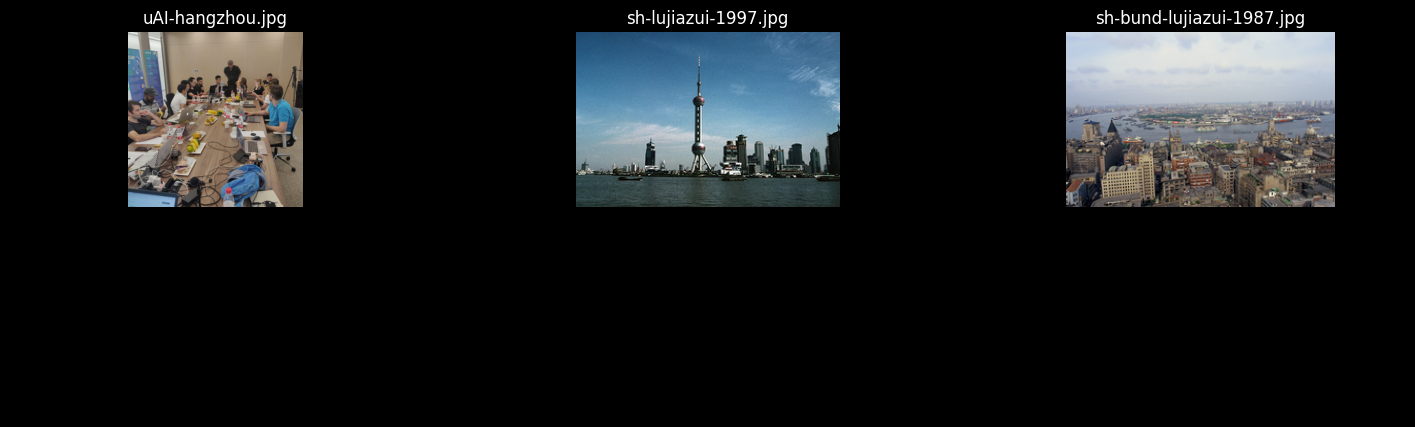

In [ ]:
p2imgs = Path('../imgs')
assert p2imgs.is_dir(), "The directory 'imgs' does not exist."
loimgs = sorted([f for f in p2imgs.glob('*.jpg')])
loimgs.reverse()

fig, axs = plt.subplots(2, len(loimgs)//2 if len(loimgs)%2==0 else len(loimgs)//2 + 1, figsize=(18, 5))
for ax in axs.flatten(): ax.axis('off')
for ax, f in zip(axs.flatten(), loimgs):
    im = Image.open(f)
    im.thumbnail((256, 256), Image.Resampling.LANCZOS)
    ax.imshow(im)
    ax.set_title(f.name)
plt.show()    

Model: `granite3.2-vision:latest`

Question: **What is in this image? Give me a detailed description**

Image File: **uAI-hangzhou.jpg**


The image depicts a collaborative work environment, likely during a workshop or team meeting. The presence of laptops suggests that the individuals are engaged in tasks that require digital tools, such as programming, writing, or data analysis. The casual attire and relaxed postures indicate an informal setting, possibly within a startup culture where formal dress codes are not enforced. The use of bananas as placemats could be a creative touch to add a playful element to the workspace. The presence of water bottles and snacks implies that the event is intended to be long-lasting, allowing participants to stay hydrated and energized throughout the session. The camera on a tripod suggests that the meeting may be recorded or live-streamed for wider distribution or archival purposes. Overall, the image conveys a sense of teamwork and productivity in a modern, possibly tech-oriented workplace.

Done! in 903 characters.


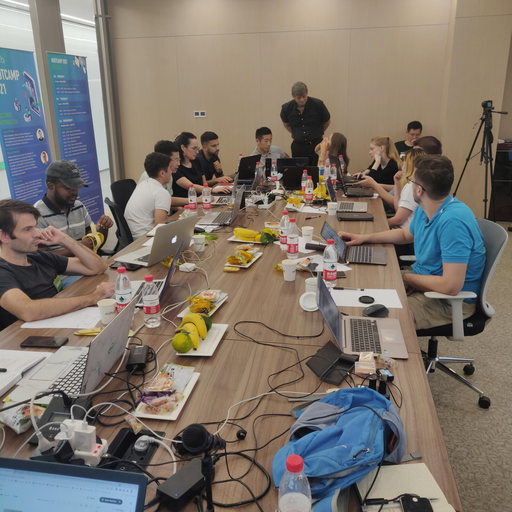

Model: `granite3.2-vision:latest`

Question: **What is in this image? Give me a detailed description**

Image File: **sh-lujiazui-1997.jpg**


The image captures a cityscape with a prominent skyscraper that resembles the Oriental Pearl Tower, which is a well-known landmark of Shanghai, China. The tower's distinctive red and white coloring makes it stand out against the blue sky. The surrounding buildings are modern in design, suggesting a contemporary urban environment. The water body in the foreground adds a serene element to the otherwise bustling cityscape. The absence of people or vehicles could imply that the photo was taken at a time when the area is less busy or from a vantage point where such details are not easily discernible. The clear sky indicates fair weather conditions, which might be conducive for outdoor activities or simply enjoying the view.

Done! in 729 characters.


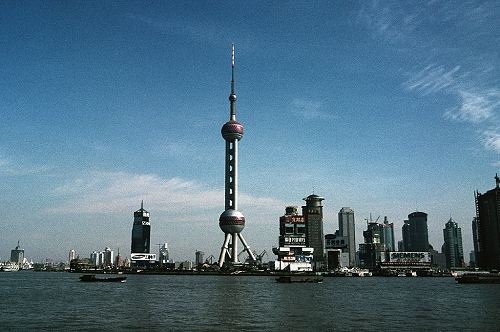

Model: `granite3.2-vision:latest`

Question: **What is in this image? Give me a detailed description**

Image File: **sh-bund-lujiazui-1987.jpg**


The image captures a densely populated urban area with a significant body of water running through it. This could be a river or a bay, given the presence of numerous boats and ships. The architecture suggests a city that has developed over time, with buildings varying in height and design, indicating different periods of construction and possibly different uses for each structure. The lack of visible greenery might imply an urban environment where space is at a premium or that the image was taken during a season when trees are not in full bloom. The overcast sky suggests it could be either early morning or late afternoon, times when the light is softer and shadows are longer. There's no visible activity on the water, which might indicate a moment of calmness or that this area is not heavily trafficked at the time the photo was taken. The image does not provide any direct information about the location or the specific city, but it offers a glimpse into urban planning and the interaction between land and water in a densely populated metropolis.

Done! in 1,059 characters.


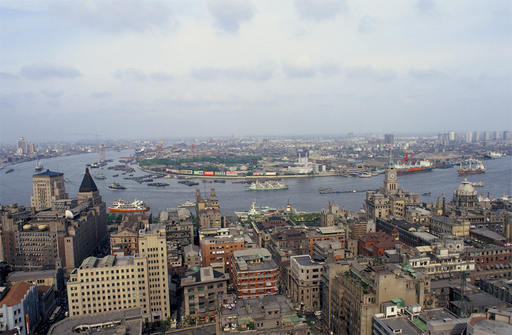

In [ ]:
model_checkpoint = 'llava:7b'
model_checkpoint = 'granite3.2-vision:latest'

for im in loimgs:
    output = send_image_to_llm(message="What is in this image? Give me a detailed description", image_path=im, model=model_checkpoint, streaming=True)

## Code Model

In [22]:
model_checkpoint = 'codellama:7b'
message = "how do i create a function in python to add a and b?"


output = send_message_to_llm(message=message, model=model_checkpoint, streaming=True)

Model: `codellama:7b`

Answer to: **how do i create a function in python to add a and b?**


To create a function in Python that adds two numbers, you can use the following syntax:
```
def add(a, b):
    return a + b
```
This defines a function called `add` that takes two arguments, `a` and `b`, and returns their sum. You can then call this function by passing in the values you want to add, like this:
```
result = add(3, 5)
print(result) # prints 8
```
This would print the result of adding 3 and 5, which is 8.

You can also use a lambda function to create an anonymous function that adds two numbers. Here's an example:
```
add_two = lambda a, b: a + b
result = add_two(3, 5)
print(result) # prints 8
```
This is equivalent to the previous example, but it doesn't require you to define a separate function.

Done! in 720 characters.


Test the code:

In [23]:
def add(a, b):
    return a + b

print(add(3, 4))

7


In [24]:
model_checkpoint = 'codellama:7b'
message = "what is the minimum code to create a random forest classifer in scikit-learn?"


output = send_message_to_llm(message=message, model=model_checkpoint, streaming=True)

Model: `codellama:7b`

Answer to: **what is the minimum code to create a random forest classifer in scikit-learn?**

Computing ...

Done! in 1,509 characters.


Test the code:

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn import datasets
from sklearn.model_selection import train_test_split

# Load the dataset
iris = datasets.load_iris()
X = iris.data[:, :2]  # we only take the first two features.
y = iris.target

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Random Forest Classifier
clf = RandomForestClassifier(n_estimators=10, random_state=42)

# Train the model on the training data
clf.fit(X_train, y_train)

# Predict the labels of the test data
y_pred = clf.predict(X_test)

# Evaluate the performance of the model
accuracy = clf.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.7666666666666667


## SQL Model

### Function for simple query to database

In [26]:
query_db("SELECT * FROM accounts")

,uid,account_name,city,country
0,1,TechStyle Inc,Tokyo,Japan
1,2,FashionHub Inc,Tokyo,Japan
2,3,ModernWear Inc,Shenzhen,PRC
3,4,GlobalTextile Inc,Seoul,Korea
4,5,UrbanThread Inc,Shanghai,PRC
5,6,StyleCraft Inc,Shenzhen,PRC
6,7,PremiumFabric Inc,Seoul,Korea
7,8,ElegantWear Inc,Beijing,PRC
8,9,TrendSetter Inc,Shanghai,PRC
9,10,ChicOutfit Inc,Shanghai,PRC


In [27]:
model_checkpoint = 'codellama:7b'
message = f"""
This is a database scheme: {db_schema}. 
Give me the sql statement to list all companies in the database.
"""

output = send_message_llm_for_sql(message=message, model=model_checkpoint)
print('\nLLM output:')
display(Markdown(f"```ascii\n{output}```"))
print('')
print('Extracted Code:')
display(Markdown(f"```sql\n{extract_sql(output)}\n```"))

Model: `codellama:7b`

Done! in 212 characters.

LLM output:


```ascii
 Here is an SQL query that will display all of the companies in your database:
```
SELECT account_name FROM accounts;
```
This will return a result set containing all of the company names in the `accounts` table.```


Extracted Code:


```sql
SELECT account_name FROM accounts;
```

Test the SQL:

In [28]:
sql = extract_sql(output)

query_db(sql)

,account_name
0,TechStyle Inc
1,FashionHub Inc
2,ModernWear Inc
3,GlobalTextile Inc
4,UrbanThread Inc
5,StyleCraft Inc
6,PremiumFabric Inc
7,ElegantWear Inc
8,TrendSetter Inc
9,ChicOutfit Inc


In [29]:
model_checkpoint = 'codellama:7b'
co_name = 'FashionHub Inc'

message = f"Give me the sql statement to get all orders which were placed by {co_name} with all details."


output = send_message_llm_for_sql(message=message, model=model_checkpoint)
print('\nLLM output:')
display(Markdown(f"```ascii\n{output}```"))
print('')
print('Extracted Code:')
display(Markdown(f"```sql\n{extract_sql(output)}\n```"))

Model: `codellama:7b`

Done! in 499 characters.

LLM output:


```ascii

Here is a SQL query that should retrieve all orders placed by FashionHub Inc:
```
SELECT * 
FROM orders 
WHERE company_name = 'FashionHub Inc';
```
This will return all columns (`*`) from the `orders` table where the `company_name` column matches the value `'FashionHub Inc'`.

Note that this query assumes that the `orders` table has a column named `company_name` and that you are using a SQL database. If your table has a different name or structure, you may need to modify the query accordingly.```


Extracted Code:


```sql
SELECT * 
FROM orders 
WHERE company_name = 'FashionHub Inc';
```

In [30]:
try:
    result = query_db(extract_sql(output))
    display(result)
except Exception as e:
    print(f"Error executing SQL: \n{e}")

Error executing SQL: 
Execution failed on sql 'SELECT * 
FROM orders 
WHERE company_name = 'FashionHub Inc';': no such column: company_name


In [31]:
# Query all order details for FashionHub Inc
co_name = 'FashionHub Inc'
sql = f"""
SELECT 
    a.account_name,
    a.city,
    a.country,
    o.uid as order_id,
    o.order_date,
    o.status,
    p.product_name,
    p.product_price,
    od.quantity,
    (p.product_price * od.quantity) as line_total
FROM accounts a
JOIN orders o ON a.uid = o.account_id
JOIN order_details od ON o.uid = od.order_id
JOIN products p ON od.product_id = p.uid
WHERE a.account_name = "{co_name}"
ORDER BY o.order_date DESC, o.uid
"""
df = query_db(sql)
print(f"{co_name} ordered a total of {df.line_total.sum():,.2f}")
display(df)

FashionHub Inc ordered a total of 7,514.24


,account_name,city,country,order_id,order_date,status,product_name,product_price,quantity,line_total
0,FashionHub Inc,Tokyo,Japan,36,2024-12-24,Cancelled,Cotton T-Shirt,19.99,2,39.98
1,FashionHub Inc,Tokyo,Japan,36,2024-12-24,Cancelled,Chinos,54.99,10,549.90
2,FashionHub Inc,Tokyo,Japan,48,2024-12-20,Processing,Leather Jacket,149.99,10,1499.90
3,FashionHub Inc,Tokyo,Japan,48,2024-12-20,Processing,Trench Coat,179.99,6,1079.94
4,FashionHub Inc,Tokyo,Japan,48,2024-12-20,Processing,Tank Top,14.99,4,59.96
5,FashionHub Inc,Tokyo,Japan,48,2024-12-20,Processing,Tank Top,14.99,3,44.97
6,FashionHub Inc,Tokyo,Japan,48,2024-12-20,Processing,Silk Blouse,89.99,2,179.98
7,FashionHub Inc,Tokyo,Japan,24,2024-09-17,Shipped,Bomber Jacket,119.99,7,839.93
8,FashionHub Inc,Tokyo,Japan,24,2024-09-17,Shipped,Wool Sweater,79.99,7,559.93
9,FashionHub Inc,Tokyo,Japan,22,2024-08-06,Processing,Cashmere Scarf,84.99,6,509.94


### Agentic Version of SQL LLM

In [32]:
def llm_query_loop(message, max_attempts=10, model='codellama:7b'):
    """Loop to refine SQL query based on LLM feedback"""
    attempt = 0
    correct_sql = False
    outputs = []
    sqls = []
    while not correct_sql and attempt < max_attempts:
        display(Markdown(f"**Attempt {attempt+1}**:"))
        # Get LLM response
        output = send_message_llm_for_sql(message=message, model=model)   
        outputs.append(output)
        # Extract SQL
        sql = extract_sql(output)
        sqls.append(sql)
        display(Markdown(f"```sql\n{sql}\n```"))
        # Test it
        try:
            result = query_db(sql)
            print(f"\n✓ Query successful!")
            correct_sql = True
            return sql, result, sqls, outputs
        except Exception as e:
            print(f"\n✗ Query {attempt+1} failed test!")
            attempt += 1
            # Modify the user message to provide the question, the wrong SQL and the error message
            message = f"""
            This is a database schema: {db_schema}
            Generate a SQL statement that answer the following question:
                Question: {question}
            Return ONLY the SQL statement without explanation. Start directly with SELECT/INSERT/UPDATE/DELETE.
            
            Generated SQL statement:
            ```sql
            {sql}
            ```
            When running the above SQL, the following error was raised: {e}

            Correct the SQL statement and provide the corrected SQL statement for the question.
            Return ONLY the SQL statement without explanation. Start directly with SELECT/INSERT/UPDATE/DELETE.
            """
    print("\n✗ Query failed for too many attempts.")
    return None, None, sqls, outputs


In [33]:
def ask_llm_for_sql(question, model='codellama:7b'):
    """Ask LLM for SQL and automatically extract and test it"""
    message = f"""
    This is a database schema: {db_schema}
    Generate a SQL statement that answer the following question:
        Question: {question}
    Return ONLY the SQL statement without explanation. Start directly with SELECT/INSERT/UPDATE/DELETE.
    """

    max_attempts = 5
    sql, result, sqls, outputs = llm_query_loop(message, max_attempts, model)
    if sql:
        return sql, result, sqls, outputs
    else:
        max_attempts = 5
        sql, result, sqls, outputs = llm_query_loop(message, max_attempts, model)
        if sql:
            return sql, result, sqls, outputs
        else:
            print(f"\n✗ Query {max_attempts} attempts failed test!")    
            return None, None, sqls, outputs

In [34]:
question = "List of all that companies"

sql, result, sqls, output = ask_llm_for_sql(question)

if result is not None:
    display(result)

**Attempt 1**:

Model: `codellama:7b`

Done! in 23 characters.


```sql
SELECT * FROM accounts;
```


✓ Query successful!


,uid,account_name,city,country
0,1,TechStyle Inc,Tokyo,Japan
1,2,FashionHub Inc,Tokyo,Japan
2,3,ModernWear Inc,Shenzhen,PRC
3,4,GlobalTextile Inc,Seoul,Korea
4,5,UrbanThread Inc,Shanghai,PRC
5,6,StyleCraft Inc,Shenzhen,PRC
6,7,PremiumFabric Inc,Seoul,Korea
7,8,ElegantWear Inc,Beijing,PRC
8,9,TrendSetter Inc,Shanghai,PRC
9,10,ChicOutfit Inc,Shanghai,PRC


In [35]:
question = """
Get the list of all orders with all order and product details for account FashionHub Inc. 
Add the total price per order line. 
Order them by ascending order date
"""

sql, result, sqls, outputs = ask_llm_for_sql(question)

if result is not None:
    display(result)

**Attempt 1**:

Model: `codellama:7b`

Done! in 346 characters.


```sql
SELECT orders.uid, orders.order_date, orders.status, products.product_name, products.product_price, order_details.quantity
FROM orders 
LEFT JOIN product_details ON (orders.uid = order_details.order_id)
LEFT JOIN products ON (products.uid = order_details.product_id)
WHERE accounts.account_name = 'FashionHub Inc.'
ORDER BY orders.order_date ASC;
```


✗ Query 1 failed test!


...

Model: `codellama:7b`

Done! in 435 characters.


```sql
SELECT orders.uid, orders.order_date, orders.status, products.product_name, products.product_price, order_details.quantity, (products.product_price * order_details.quantity) AS total_price
FROM orders
JOIN order_details ON orders.uid = order_details.order_id
JOIN products ON order_details.product_id = products.uid
WHERE account_id IN (SELECT uid FROM accounts WHERE account_name LIKE 'FashionHub Inc')
ORDER BY orders.order_date ASC;
```


✓ Query successful!


,uid,order_date,status,product_name,product_price,quantity,total_price
0,30,2024-01-09,Cancelled,Blazer,129.99,7,909.93
1,30,2024-01-09,Cancelled,Wool Sweater,79.99,8,639.92
2,22,2024-08-06,Processing,Cashmere Scarf,84.99,6,509.94
3,22,2024-08-06,Processing,Leather Jacket,149.99,4,599.96
4,24,2024-09-17,Shipped,Bomber Jacket,119.99,7,839.93
5,24,2024-09-17,Shipped,Wool Sweater,79.99,7,559.93
6,48,2024-12-20,Processing,Leather Jacket,149.99,10,1499.90
7,48,2024-12-20,Processing,Trench Coat,179.99,6,1079.94
8,48,2024-12-20,Processing,Tank Top,14.99,4,59.96
9,48,2024-12-20,Processing,Tank Top,14.99,3,44.97


In [36]:
# Query all order details for FashionHub Inc
co_name = 'FashionHub Inc'
sql = f"""
SELECT 
    a.account_name,
    a.city,
    a.country,
    o.uid as order_id,
    o.order_date,
    o.status,
    p.product_name,
    p.product_price,
    od.quantity,
    (p.product_price * od.quantity) as line_total
FROM accounts a
JOIN orders o ON a.uid = o.account_id
JOIN order_details od ON o.uid = od.order_id
JOIN products p ON od.product_id = p.uid
WHERE a.account_name = "{co_name}"
ORDER BY o.order_date ASC
"""
df = query_db(sql)
print(f"{co_name} ordered a total of {df.line_total.sum():,.2f}")
display(df)

FashionHub Inc ordered a total of 7,514.24


,account_name,city,country,order_id,order_date,status,product_name,product_price,quantity,line_total
0,FashionHub Inc,Tokyo,Japan,30,2024-01-09,Cancelled,Blazer,129.99,7,909.93
1,FashionHub Inc,Tokyo,Japan,30,2024-01-09,Cancelled,Wool Sweater,79.99,8,639.92
2,FashionHub Inc,Tokyo,Japan,22,2024-08-06,Processing,Cashmere Scarf,84.99,6,509.94
3,FashionHub Inc,Tokyo,Japan,22,2024-08-06,Processing,Leather Jacket,149.99,4,599.96
4,FashionHub Inc,Tokyo,Japan,24,2024-09-17,Shipped,Bomber Jacket,119.99,7,839.93
5,FashionHub Inc,Tokyo,Japan,24,2024-09-17,Shipped,Wool Sweater,79.99,7,559.93
6,FashionHub Inc,Tokyo,Japan,48,2024-12-20,Processing,Leather Jacket,149.99,10,1499.90
7,FashionHub Inc,Tokyo,Japan,48,2024-12-20,Processing,Trench Coat,179.99,6,1079.94
8,FashionHub Inc,Tokyo,Japan,48,2024-12-20,Processing,Tank Top,14.99,4,59.96
9,FashionHub Inc,Tokyo,Japan,48,2024-12-20,Processing,Tank Top,14.99,3,44.97


In [37]:
question = """
List all orders for account FashionHub Inc, including the total price for each order. 
List the following fields: account name, order date, order ID and total price of the order
"""

sql, result, sqls, outputs = ask_llm_for_sql(question)

if result is not None:
    display(result)

**Attempt 1**:

Model: `codellama:7b`

Done! in 281 characters.


```sql
SELECT A.account_name, O.order_date, O.uid AS order_id, SUM(P.product_price*OD.quantity) as total_price
FROM accounts A
JOIN orders O ON O.account_id=A.uid
JOIN order_details OD ON O.uid = OD.order_id
JOIN products P ON OD.product_id = P.uid
WHERE A.account_name = 'FashionHub Inc'
```


✓ Query successful!


,account_name,order_date,order_id,total_price
0,FashionHub Inc,2024-08-06,22,7514.24


In [38]:
question = """
List all orders with all order details for accounts FashionHub Inc and for PremiumFabric Inc.
Show the following fields: account name, order date, order ID, product name, product price, quantity and line total.
Order by account ID first, then by order date.
"""

sql, result, sqls, outputs = ask_llm_for_sql(question)

if result is not None:
    display(result)

**Attempt 1**:

Model: `codellama:7b`

Done! in 489 characters.


```sql
SELECT a.account_name AS "Account Name", o.order_date AS "Order Date", o.uid AS "Order ID", p.product_name AS "Product Name", p.product_price AS "Product Price", od.quantity AS "Quantity", (od.quantity * p.product_price) AS "Line Total"
FROM orders o
INNER JOIN order_details od ON o.uid = od.order_id
INNER JOIN products p ON od.product_id = p.uid
INNER JOIN accounts a ON o.account_id = a.uid
WHERE a.account_name IN ('FashionHub Inc', 'PremiumFabric Inc')
ORDER BY a.uid, o.order_date;
```


✓ Query successful!


,Account Name,Order Date,Order ID,Product Name,Product Price,Quantity,Line Total
0,FashionHub Inc,2024-01-09,30,Blazer,129.99,7,909.93
1,FashionHub Inc,2024-01-09,30,Wool Sweater,79.99,8,639.92
2,FashionHub Inc,2024-08-06,22,Cashmere Scarf,84.99,6,509.94
3,FashionHub Inc,2024-08-06,22,Leather Jacket,149.99,4,599.96
4,FashionHub Inc,2024-09-17,24,Bomber Jacket,119.99,7,839.93
5,FashionHub Inc,2024-09-17,24,Wool Sweater,79.99,7,559.93
6,FashionHub Inc,2024-12-20,48,Leather Jacket,149.99,10,1499.90
7,FashionHub Inc,2024-12-20,48,Trench Coat,179.99,6,1079.94
8,FashionHub Inc,2024-12-20,48,Tank Top,14.99,4,59.96
9,FashionHub Inc,2024-12-20,48,Tank Top,14.99,3,44.97


# End